# Hospital Readmission Prediction Using Machine Learning

## Thiranex Internship – Project 4

### Objective
To develop a machine learning model that predicts whether a diabetic patient is likely to be readmitted to the hospital within 30 days.

### Dataset
UCI Diabetes 130-US Hospitals for Years 1999–2008

### Machine Learning Models
- Logistic Regression
- Random Forest Classifier

### Evaluation
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Feature Importance
- Threshold Tuning

In [ ]:
import zipfile
import os
import glob

# Find the uploaded ZIP file
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")
print(zip_files)

# Use the first ZIP file found
zip_path = zip_files[0]

# Folder where we will extract the dataset
extract_path = "/content/diabetes_dataset"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("\nDataset extracted successfully!")
print("Extracted files:")
print(os.listdir(extract_path))

ZIP files found:
['/content/diabetes+130-us+hospitals+for+years+1999-2008.zip']

Dataset extracted successfully!
Extracted files:
['IDS_mapping.csv', 'diabetic_data.csv']


In [ ]:
import pandas as pd

# Load the main dataset
df = pd.read_csv("/content/diabetes_dataset/diabetic_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (101766, 50)


In [ ]:
# Display the first 5 rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
# Count '?' values in each column
question_marks = (df == '?').sum()

# Count actual missing (NaN) values
missing_values = df.isnull().sum()

# Combine both
missing_summary = pd.DataFrame({
    'Question_Marks': question_marks,
    'NaN_Values': missing_values
})

# Show only columns containing missing/unknown values
missing_summary[
    (missing_summary['Question_Marks'] > 0) |
    (missing_summary['NaN_Values'] > 0)
].sort_values(
    by=['Question_Marks', 'NaN_Values'],
    ascending=False
)

,Question_Marks,NaN_Values
weight,98569,0
medical_specialty,49949,0
payer_code,40256,0
race,2273,0
diag_3,1423,0
diag_2,358,0
diag_1,21,0
max_glu_serum,0,96420
A1Cresult,0,84748


In [ ]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check the values and counts of the target variable
print(df['readmitted'].value_counts())

print("\nPercentage distribution:")
print(df['readmitted'].value_counts(normalize=True) * 100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentage distribution:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


In [ ]:
# Create binary target variable
df['early_readmission'] = (df['readmitted'] == '<30').astype(int)

# Check the new target distribution
print(df['early_readmission'].value_counts())

print("\nPercentage distribution:")
print(df['early_readmission'].value_counts(normalize=True) * 100)

early_readmission
0    90409
1    11357
Name: count, dtype: int64

Percentage distribution:
early_readmission
0    88.840084
1    11.159916
Name: proportion, dtype: float64


In [ ]:
# Count '?' values in each column
question_marks = (df == '?').sum()

# Display only columns containing '?'
question_marks[question_marks > 0].sort_values(ascending=False)

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [ ]:
# Remove columns with excessive unknown values
df = df.drop(columns=['weight', 'medical_specialty', 'payer_code'])

# Replace '?' with 'Unknown' in the remaining columns
df = df.replace('?', 'Unknown')

# Check the new dataset shape
print("Dataset shape after cleaning:", df.shape)

# Check that '?' values are gone
print("\nRemaining '?' values:", (df == '?').sum().sum())

Dataset shape after cleaning: (101766, 48)

Remaining '?' values: 0


In [ ]:
# Check for actual missing (NaN) values
missing_values = df.isnull().sum()

# Display only columns that contain missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
max_glu_serum,96420
A1Cresult,84748


In [ ]:
# Remove columns with excessive missing values
df = df.drop(columns=['max_glu_serum', 'A1Cresult'])

# Check the updated dataset shape
print("Dataset shape after handling missing values:", df.shape)

# Confirm no missing values remain
print("\nTotal missing values:", df.isnull().sum().sum())

Dataset shape after handling missing values: (101766, 46)

Total missing values: 0


In [ ]:
# Display the data type of every column
print(df.dtypes.value_counts())

print("\nNumerical columns:")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=['object']).columns.tolist())

object    32
int64     14
Name: count, dtype: int64

Numerical columns:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'early_readmission']

Categorical columns:
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [ ]:
# Remove identifier columns and the original target column
df = df.drop(columns=[
    'encounter_id',
    'patient_nbr',
    'readmitted'
])

# Check the updated dataset shape
print("Dataset shape:", df.shape)

# Display remaining columns
print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape: (101766, 43)

Remaining columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'early_readmission']


In [ ]:
# Get all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Display the number of unique values in each categorical column
unique_counts = df[categorical_columns].nunique().sort_values(ascending=False)

print("Unique values in categorical columns:")
print(unique_counts)

Unique values in categorical columns:
diag_3                      790
diag_2                      749
diag_1                      717
age                          10
race                          6
metformin                     4
repaglinide                   4
glipizide                     4
nateglinide                   4
chlorpropamide                4
glimepiride                   4
glyburide                     4
acarbose                      4
rosiglitazone                 4
pioglitazone                  4
glyburide-metformin           4
insulin                       4
miglitol                      4
gender                        3
tolazamide                    3
acetohexamide                 2
tolbutamide                   2
troglitazone                  2
metformin-rosiglitazone       2
metformin-pioglitazone        2
glipizide-metformin           2
glimepiride-pioglitazone      2
change                        2
diabetesMed                   2
citoglipton                   1
ex

In [ ]:
# Find columns with only one unique value
constant_columns = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:")
print(constant_columns)

# Remove constant columns
df = df.drop(columns=constant_columns)

print("\nDataset shape after removing constant columns:", df.shape)

Constant columns:
['examide', 'citoglipton']

Dataset shape after removing constant columns: (101766, 41)


In [ ]:
# Display summary statistics for numerical features
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


In [ ]:
# Convert ID-based categorical features from numbers to categorical data
id_categorical_columns = [
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id'
]

df[id_categorical_columns] = df[id_categorical_columns].astype(str)

# Check the updated data types
print(df[id_categorical_columns].dtypes)

admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object


In [ ]:
# Separate input features and target
X = df.drop(columns=['early_readmission'])
y = df['early_readmission']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (101766, 40)
Target shape: (101766,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (81412, 40)
Testing features: (20354, 40)
Training target: (81412,)
Testing target: (20354,)


In [ ]:
# Identify numerical and categorical features
numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 8
Number of categorical features: 32

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing for numerical features
numerical_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# Fit the preprocessing pipeline on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (81412, 2318)
Processed testing shape: (20354, 2318)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_processed)

# Get probability of early readmission
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Logistic Regression Results
----------------------------
Accuracy : 0.6610002947823523
Precision: 0.18000829531314808
Recall   : 0.5733157199471598
F1-Score : 0.273989898989899
ROC-AUC  : 0.6703746044250722


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make predictions on the test set
rf_pred = random_forest_model.predict(X_test_processed)

# Get probability of early readmission
rf_prob = random_forest_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Accuracy : 0.8886214011987815
Precision: 0.6428571428571429
Recall   : 0.003963011889035667
F1-Score : 0.00787746170678337
ROC-AUC  : 0.6761983181763292


In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Test different probability thresholds
thresholds = np.arange(0.10, 0.51, 0.05)

print("Threshold | Precision | Recall | F1-Score")
print("------------------------------------------")

for threshold in thresholds:
    predictions = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"{threshold:.2f}      | "
        f"{precision:.3f}     | "
        f"{recall:.3f}  | "
        f"{f1:.3f}"
    )

Threshold | Precision | Recall | F1-Score
------------------------------------------
0.10      | 0.162     | 0.693  | 0.262
0.15      | 0.222     | 0.378  | 0.280
0.20      | 0.303     | 0.195  | 0.237
0.25      | 0.380     | 0.096  | 0.153
0.30      | 0.493     | 0.049  | 0.090
0.35      | 0.617     | 0.029  | 0.056
0.40      | 0.633     | 0.014  | 0.027
0.45      | 0.630     | 0.007  | 0.015
0.50      | 0.643     | 0.004  | 0.008


In [31]:
# Select the best threshold based on F1-score
best_threshold = 0.15

# Generate final predictions using the selected threshold
final_pred = (rf_prob >= best_threshold).astype(int)

# Calculate final metrics
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("Selected Threshold:", best_threshold)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1-Score:", final_f1)

Selected Threshold: 0.15
Precision: 0.21482530689329557
Recall: 0.4007045354469397
F1-Score: 0.2796987859228523


Confusion Matrix:
[[14757  3326]
 [ 1361   910]]


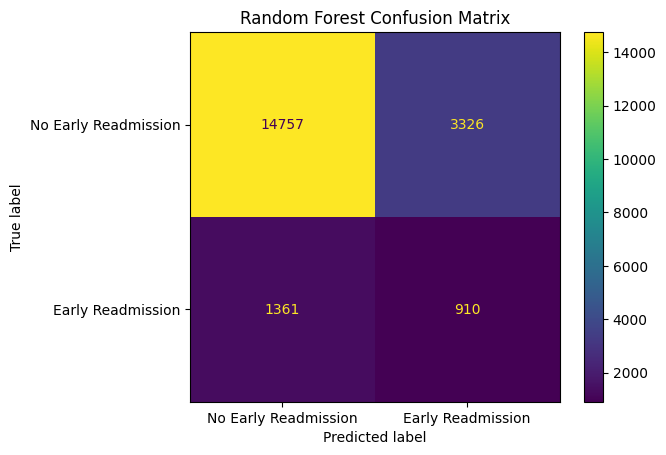

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, final_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Early Readmission", "Early Readmission"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

ROC-AUC Score: 0.6761983181763292


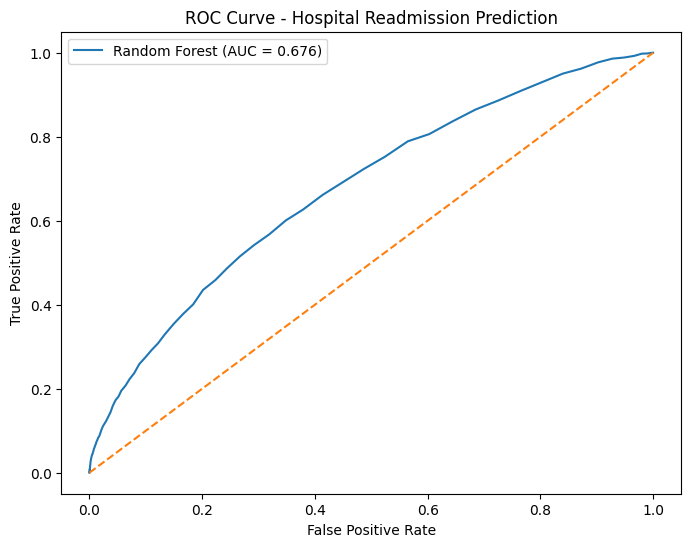

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression predictions
log_pred = logistic_model.predict(X_test_processed)
log_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate Logistic Regression metrics
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_roc_auc = roc_auc_score(y_test, log_prob)

# Random Forest at threshold 0.15
rf_tuned_accuracy = accuracy_score(y_test, final_pred)

# Final comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (0.50)",
        "Random Forest (0.15)"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        rf_tuned_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision,
        final_precision
    ],
    "Recall": [
        log_recall,
        rf_recall,
        final_recall
    ],
    "F1-Score": [
        log_f1,
        rf_f1,
        final_f1
    ],
    "ROC-AUC": [
        log_roc_auc,
        rf_roc_auc,
        rf_roc_auc
    ]
})

print(model_comparison.round(3))

                  Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0   Logistic Regression     0.661      0.180   0.573     0.274    0.670
1  Random Forest (0.50)     0.889      0.643   0.004     0.008    0.676
2  Random Forest (0.15)     0.770      0.215   0.401     0.280    0.676


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
importance = random_forest_model.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
print("Top 20 Important Features:")
print(feature_importance.head(20))

Top 20 Important Features:
                            Feature  Importance
1           num__num_lab_procedures    0.050650
3              num__num_medications    0.046847
6             num__number_inpatient    0.039893
0             num__time_in_hospital    0.037214
7             num__number_diagnoses    0.026934
2               num__num_procedures    0.026419
4            num__number_outpatient    0.013512
5             num__number_emergency    0.012463
15                 cat__gender_Male    0.011388
14               cat__gender_Female    0.011340
35  cat__discharge_disposition_id_1    0.010910
24                 cat__age_[70-80)    0.010638
23                 cat__age_[60-70)    0.010129
10              cat__race_Caucasian    0.009543
27         cat__admission_type_id_1    0.009407
74       cat__admission_source_id_7    0.008689
8         cat__race_AfricanAmerican    0.008598
25                 cat__age_[80-90)    0.008431
28         cat__admission_type_id_2    0.008333
22           

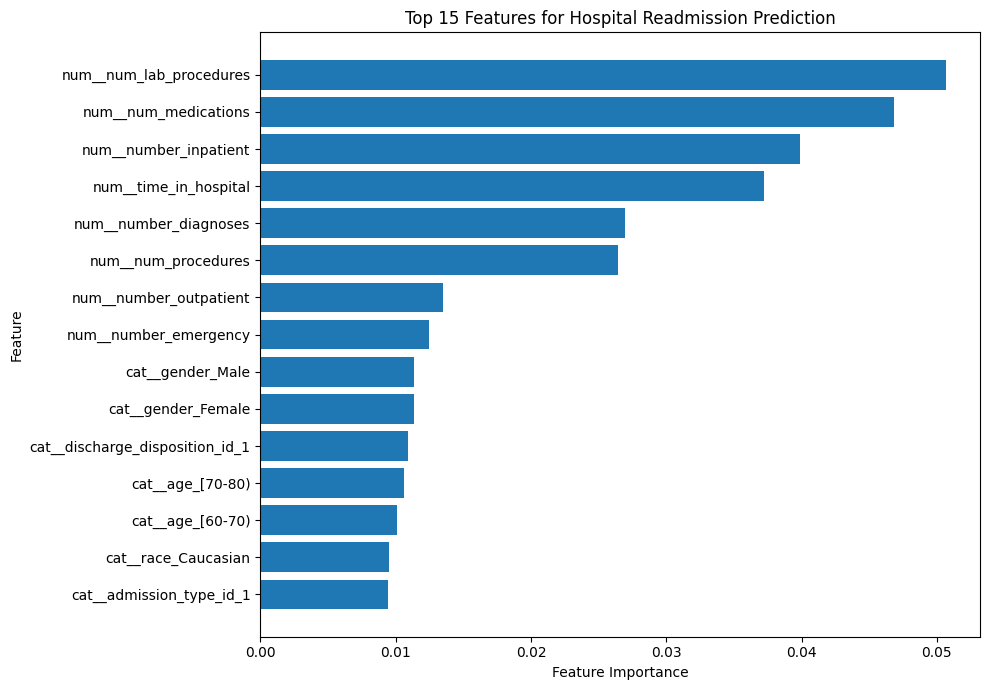

In [37]:
# Select top 15 features
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create horizontal bar chart
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Hospital Readmission Prediction")

plt.tight_layout()
plt.show()

In [38]:
# Select one patient from the test set
sample_index = X_test.index[0]

# Get the patient's processed data
sample_patient = X_test.loc[[sample_index]]
sample_patient_processed = preprocessor.transform(sample_patient)

# Predict probability of early readmission
sample_probability = random_forest_model.predict_proba(
    sample_patient_processed
)[0, 1]

# Apply our selected threshold
sample_prediction = int(sample_probability >= best_threshold)

# Get actual outcome
actual_outcome = y_test.loc[sample_index]

print("Sample Patient Prediction")
print("-------------------------")
print("Predicted Probability:", round(sample_probability, 3))
print("Selected Threshold:", best_threshold)
print("Predicted Outcome:",
      "Early Readmission" if sample_prediction == 1 else "No Early Readmission")
print("Actual Outcome:",
      "Early Readmission" if actual_outcome == 1 else "No Early Readmission")

Sample Patient Prediction
-------------------------
Predicted Probability: 0.095
Selected Threshold: 0.15
Predicted Outcome: No Early Readmission
Actual Outcome: No Early Readmission


In [39]:
import joblib

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    "readmission_preprocessor.pkl"
)

# Save the trained Random Forest model
joblib.dump(
    random_forest_model,
    "hospital_readmission_random_forest.pkl"
)

print("Models saved successfully!")
print("readmission_preprocessor.pkl")
print("hospital_readmission_random_forest.pkl")

Models saved successfully!
readmission_preprocessor.pkl
hospital_readmission_random_forest.pkl


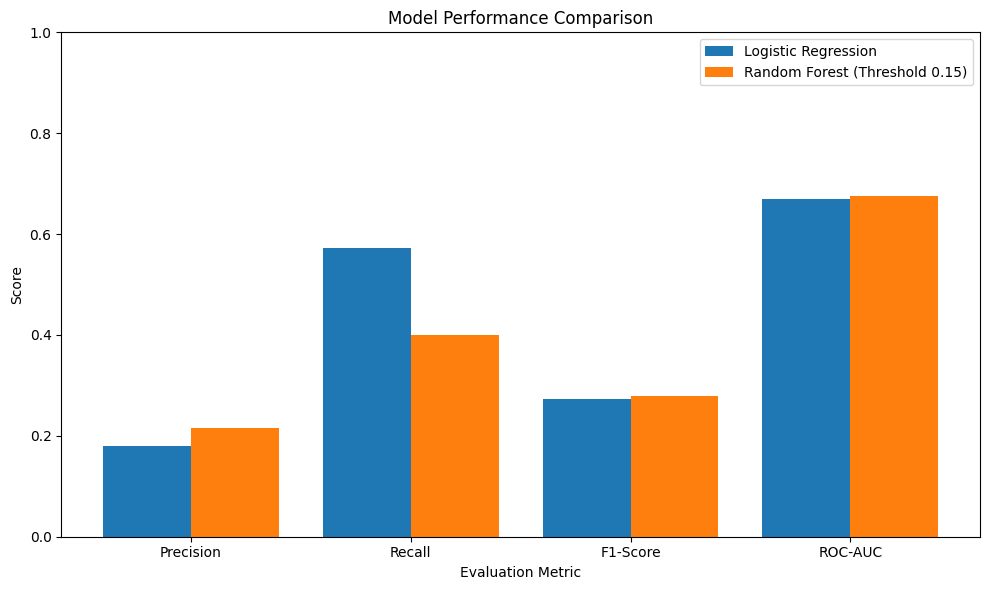

In [40]:
import matplotlib.pyplot as plt

# Select metrics for visualization
metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]

logistic_values = [
    log_precision,
    log_recall,
    log_f1,
    log_roc_auc
]

rf_tuned_values = [
    final_precision,
    final_recall,
    final_f1,
    rf_roc_auc
]

# Create comparison chart
x = range(len(metrics))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    logistic_values,
    width=0.4,
    label="Logistic Regression"
)

plt.bar(
    [i + 0.2 for i in x],
    rf_tuned_values,
    width=0.4,
    label="Random Forest (Threshold 0.15)"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

# Final Project Insights

### Dataset
- 101,766 hospital encounters from 130 U.S. hospitals.
- Target: early readmission within 30 days.
- Early readmission cases: 11.16%.
- No early readmission: 88.84%.

### Data Preparation
- Removed duplicate records.
- Replaced unknown values represented by `?`.
- Removed features with excessive missing values.
- Removed identifier columns.
- Removed constant features.
- Applied StandardScaler to numerical features.
- Applied One-Hot Encoding to categorical features.

### Model Performance
- Logistic Regression achieved 57.3% recall and 0.274 F1-score.
- Random Forest at the default 0.50 threshold achieved 88.9% accuracy but only 0.4% recall.
- Lowering the Random Forest threshold to 0.15 increased recall to 40.1% and F1-score to 0.280.
- Random Forest ROC-AUC: 0.676.

### Important Predictive Features
The most influential features included:
- Number of lab procedures
- Number of medications
- Number of inpatient visits
- Time in hospital
- Number of diagnoses
- Number of procedures

### Key Conclusion
The results show that hospital utilization, treatment intensity, and patient complexity contain useful signals for predicting early readmission. Because the target is highly imbalanced, accuracy alone is not sufficient for evaluating the model. Threshold tuning improved the Random Forest's ability to identify potential early readmission cases.

### Project Limitation
This project is based on historical public hospital-encounter data and is intended for educational and research purposes. It should not be considered a clinical diagnostic or decision-support system.

In [41]:
# Save the cleaned dataset
df.to_csv(
    "/content/cleaned_diabetes_readmission_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Shape:", df.shape)
print("File: cleaned_diabetes_readmission_dataset.csv")

Cleaned dataset saved successfully!
Shape: (101766, 41)
File: cleaned_diabetes_readmission_dataset.csv


In [44]:
from google.colab import files

files.download("/content/hospital_readmission_random_forest.pkl")
files.download("/content/readmission_preprocessor.pkl")
files.download("/content/cleaned_diabetes_readmission_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>